In [3]:

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

df = pd.read_csv("APL_Logistics.csv", encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [4]:
df.info()
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Fname                 180519 non-null  str    
 12  Customer Id                    180519 non

(180519, 40)

In [5]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [6]:
df['Customer Lname'].isnull().sum()

np.int64(8)

In [7]:
df.drop(columns=['Customer Zipcode'], inplace=True)


In [8]:
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Fname                 180519 non-null  str    
 12  Customer Id                    180519 non

In [10]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ra

In [11]:
df['Type'].unique()

<ArrowStringArray>
['DEBIT', 'PAYMENT', 'TRANSFER', 'CASH']
Length: 4, dtype: str

In [12]:
df['Type'].value_counts()

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

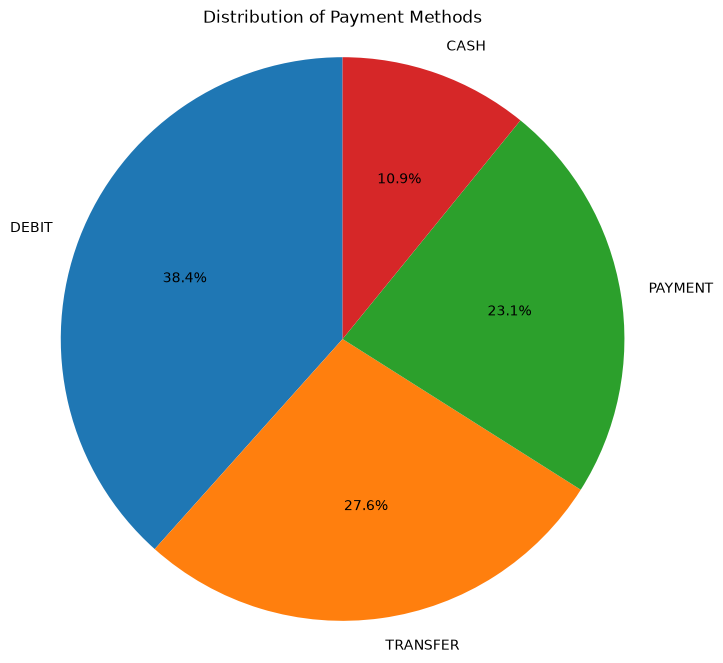

In [13]:
import matplotlib.pyplot as plt

payment_counts = df['Type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Payment Methods')
plt.axis('equal')  # makes it a perfect circle

plt.show()

In [14]:
# Dictionary of column categories

column_categories = {
    "Customer": [
        "Customer Id",
        "Customer Fname",
        "Customer Lname",
        "Customer Segment",
        "Customer City",
        "Customer Street",
        "Customer Country",
        "Customer State"
    ]
}

customer_df = df[column_categories["Customer"]]
customer_df.head()

,Customer Id,Customer Fname,Customer Lname,Customer Segment,Customer City,Customer Street,Customer Country,Customer State
0,1,Richard,Hernandez,Consumer,Brownsville,6303 Heather Plaza,EE. UU.,TX
1,2,Mary,Barrett,Consumer,Littleton,9526 Noble Embers Ridge,EE. UU.,CO
2,2,Mary,Barrett,Consumer,Littleton,9526 Noble Embers Ridge,EE. UU.,CO
3,2,Mary,Barrett,Consumer,Littleton,9526 Noble Embers Ridge,EE. UU.,CO
4,2,Mary,Barrett,Consumer,Littleton,9526 Noble Embers Ridge,EE. UU.,CO


In [15]:
product_columns = [
    "Category Id",
    "Category Name",
    "Department Id",
    "Department Name",
    "Product Name",
    "Product Price"
]

product_df = df[product_columns]
product_df.head(10)

,Category Id,Category Name,Department Id,Department Name,Product Name,Product Price
0,9,Cardio Equipment,3,Footwear,Nike Men's Free 5.0+ Running Shoe,99.99
1,29,Shop By Sport,5,Golf,Under Armour Girls' Toddler Spine Surge Runni,39.99
2,48,Water Sports,7,Fan Shop,Pelican Sunstream 100 Kayak,199.99
3,48,Water Sports,7,Fan Shop,Pelican Sunstream 100 Kayak,199.99
4,24,Women's Apparel,5,Golf,Nike Men's Dri-FIT Victory Golf Polo,50.00
5,43,Camping & Hiking,7,Fan Shop,Diamondback Women's Serene Classic Comfort Bi,299.98
6,46,Indoor/Outdoor Games,7,Fan Shop,O'Brien Men's Neoprene Life Vest,49.98
7,46,Indoor/Outdoor Games,7,Fan Shop,O'Brien Men's Neoprene Life Vest,49.98
8,45,Fishing,7,Fan Shop,Field & Stream Sportsman 16 Gun Fire Safe,399.98
9,17,Cleats,4,Apparel,Perfect Fitness Perfect Rip Deck,59.99


In [16]:
order_columns = [
    "Order Customer Id",
    "Order City",
    "Order State",
    "Order Country",
    "Order Region",
    "Order Status"
]
order_df = df[order_columns]
order_df.head()

,Order Customer Id,Order City,Order State,Order Country,Order Region,Order Status
0,1,Mumbai,Maharashtra,India,South Asia,COMPLETE
1,2,San Pedro Sula,Cortés,Honduras,Central America,ON_HOLD
2,2,San Pedro Sula,Cortés,Honduras,Central America,ON_HOLD
3,2,New York City,Nueva York,Estados Unidos,East of USA,COMPLETE
4,2,New York City,Nueva York,Estados Unidos,East of USA,COMPLETE


In [17]:
sales_profit_columns = [
    "Sales",
    "Sales per customer",
    "Benefit per order",
    "Order Profit Per Order",
    "Order Item Profit Ratio",
    "Order Item Total"
]
sales_profit_df = df[sales_profit_columns]
sales_profit_df.head()

,Sales,Sales per customer,Benefit per order,Order Profit Per Order,Order Item Profit Ratio,Order Item Total
0,499.95,472.45,159.69,159.69,0.34,472.45
1,199.95,167.96,48.71,48.71,0.29,167.96
2,199.99,181.99,87.36,87.36,0.48,181.99
3,199.99,175.99,-41.89,-41.89,-0.24,175.99
4,50.00,40.00,10.00,10.00,0.25,40.00


In [18]:
pricing_columns = [
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity"
]
pricing_df = df[pricing_columns]
pricing_df.head()

,Order Item Product Price,Order Item Discount,Order Item Discount Rate,Order Item Quantity
0,99.99,27.50,0.06,5
1,39.99,31.99,0.16,5
2,199.99,18.00,0.09,1
3,199.99,24.00,0.12,1
4,50.00,10.00,0.20,1


In [19]:
shipping_columns = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Delivery Status",
    "Late_delivery_risk"
]
shipping_df = df[shipping_columns]
shipping_df.head()

,Days for shipping (real),Days for shipment (scheduled),Shipping Mode,Delivery Status,Late_delivery_risk
0,6,4,Standard Class,Late delivery,1
1,4,4,Standard Class,Shipping on time,0
2,4,4,Standard Class,Shipping on time,0
3,6,4,Standard Class,Late delivery,1
4,6,4,Standard Class,Late delivery,1


In [20]:
geography_columns = [
    "Latitude",
    "Longitude",
    "Market"
]

geography_df = df[geography_columns]
geography_df.head()

,Latitude,Longitude,Market
0,25.953648,-97.507683,Pacific Asia
1,38.375595,-104.726021,LATAM
2,38.375595,-104.726021,LATAM
3,38.375595,-104.726021,USCA
4,38.375595,-104.726021,USCA


In [21]:
df.dtypes # wrong dts

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order City                           str
Order Country                        str
Order Customer I

In [22]:
for col in df.select_dtypes(include=['number']).columns:
    count = (df[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count} negative values")

Benefit per order: 33784 negative values
Latitude: 9 negative values
Longitude: 180414 negative values
Order Item Profit Ratio: 33784 negative values
Order Profit Per Order: 33784 negative values


In [23]:
numeric_df = df.select_dtypes(include=np.number)

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = numeric_df[(numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Days for shipping (real): 0 outliers
Days for shipment (scheduled): 0 outliers
Benefit per order: 18942 outliers
Sales per customer: 1943 outliers
Late_delivery_risk: 0 outliers
Category Id: 0 outliers
Customer Id: 1198 outliers
Department Id: 362 outliers
Latitude: 9 outliers
Longitude: 1414 outliers
Order Customer Id: 1198 outliers
Order Item Discount: 7537 outliers
Order Item Discount Rate: 0 outliers
Order Item Product Price: 2048 outliers
Order Item Profit Ratio: 17354 outliers
Order Item Quantity: 0 outliers
Sales: 488 outliers
Order Item Total: 1943 outliers
Order Profit Per Order: 18942 outliers
Product Price: 2048 outliers


In [24]:
import pandas as pd

# Columns to analyze for outliers
outlier_columns = [
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Product Price",
    "Order Item Profit Ratio",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Product Price"
]

# Dictionary to store outlier DataFrames
outlier_dfs = {}

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_dfs[col] = df[(df[col] < lower) | (df[col] > upper)]

print("Outlier DataFrames created successfully!")

Outlier DataFrames created successfully!


Column Name       : Benefit per order
Number of Outliers: 18942


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


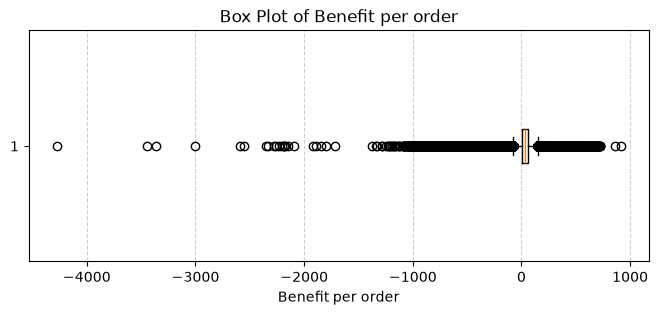

Column Name       : Sales per customer
Number of Outliers: 1943


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


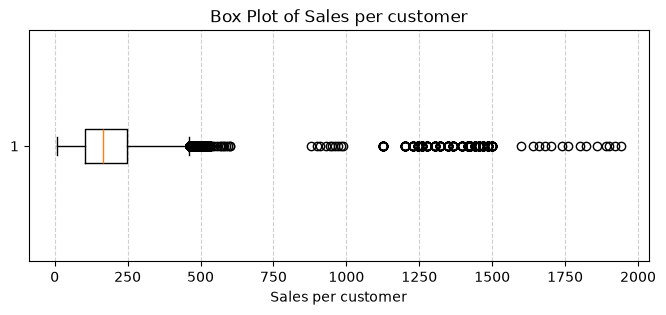

Column Name       : Order Item Discount
Number of Outliers: 7537


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


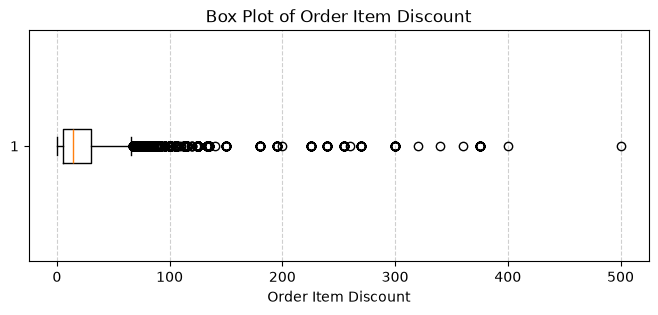

Column Name       : Order Item Product Price
Number of Outliers: 2048


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


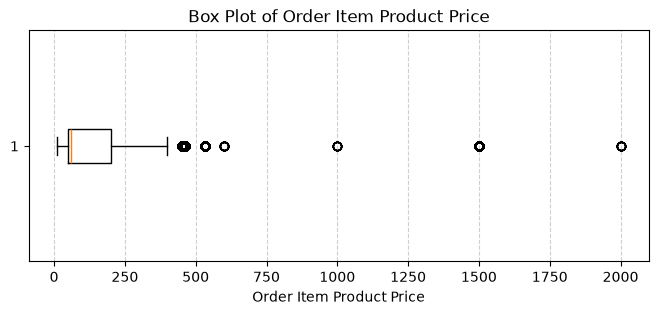

Column Name       : Order Item Profit Ratio
Number of Outliers: 17354


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


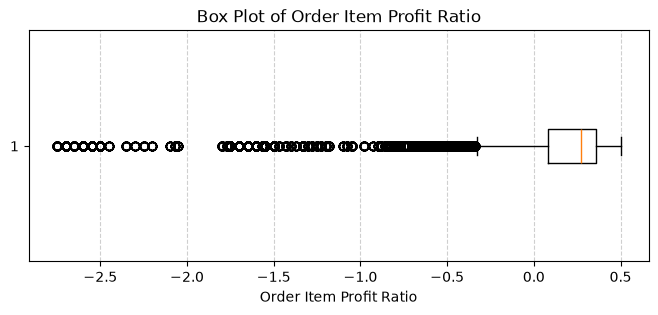

Column Name       : Sales
Number of Outliers: 488


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


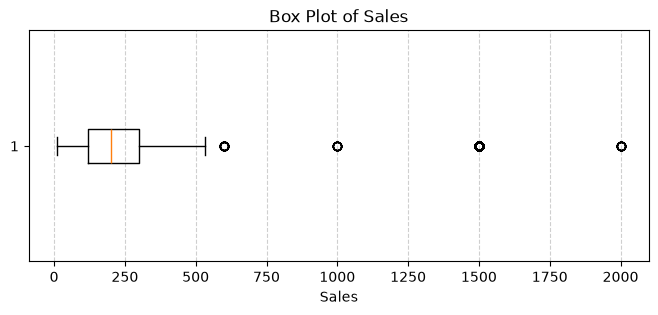

Column Name       : Order Item Total
Number of Outliers: 1943


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


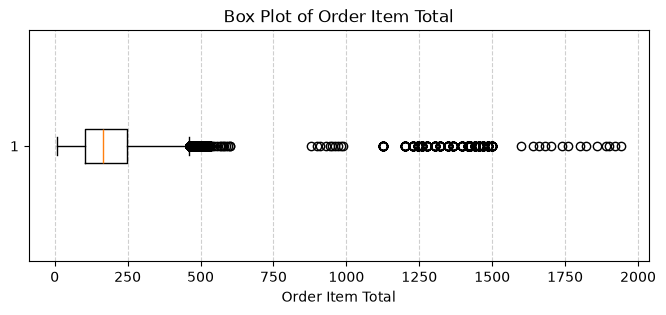

Column Name       : Order Profit Per Order
Number of Outliers: 18942


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


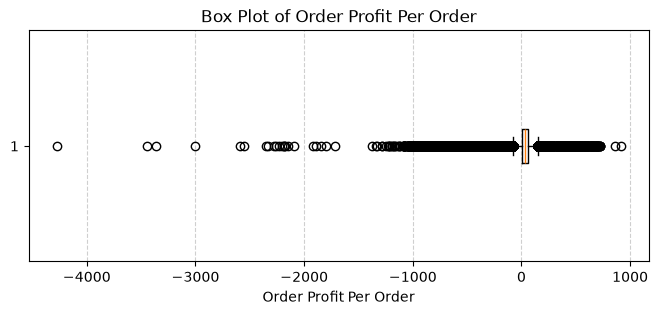

Column Name       : Product Price
Number of Outliers: 2048


C:\Users\MSI\AppData\Local\Temp\ipykernel_3076\1122199593.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


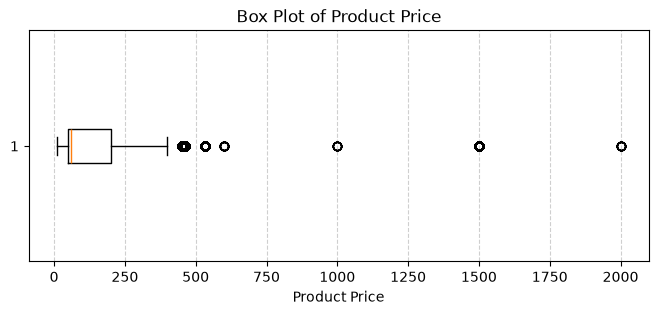

In [25]:
import matplotlib.pyplot as plt

# Columns with outliers
outlier_columns = [
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Product Price",
    "Order Item Profit Ratio",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Product Price"
]

for col in outlier_columns:
    # IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    print("=" * 80)
    print(f"Column Name       : {col}")
    print(f"Number of Outliers: {outlier_count}")
    print("=" * 80)


    plt.figure(figsize=(8, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

Histogram of Benefit per order


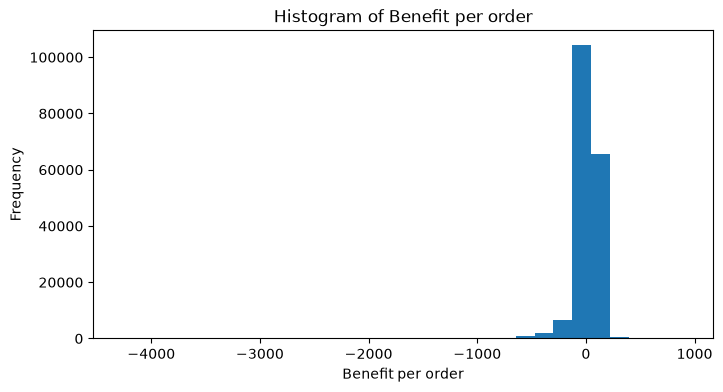

Histogram of Sales per customer


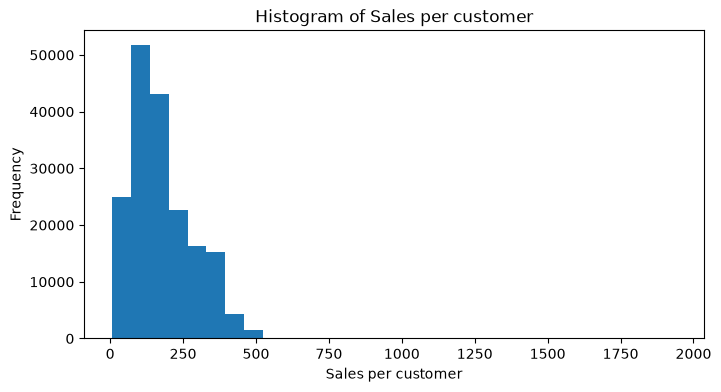

Histogram of Order Item Discount


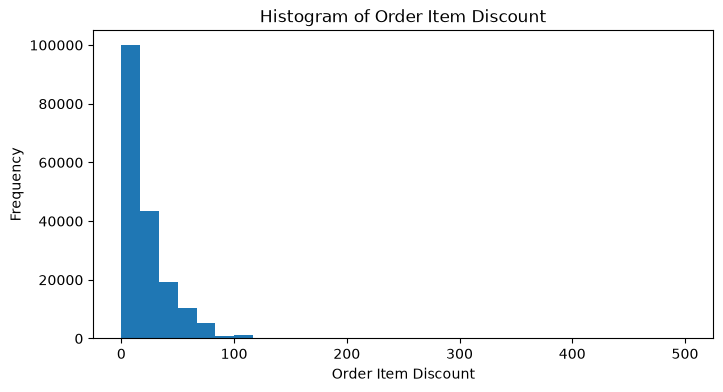

Histogram of Order Item Product Price


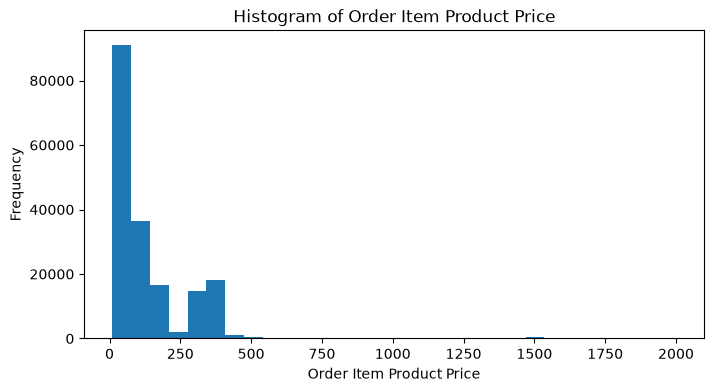

Histogram of Order Item Profit Ratio


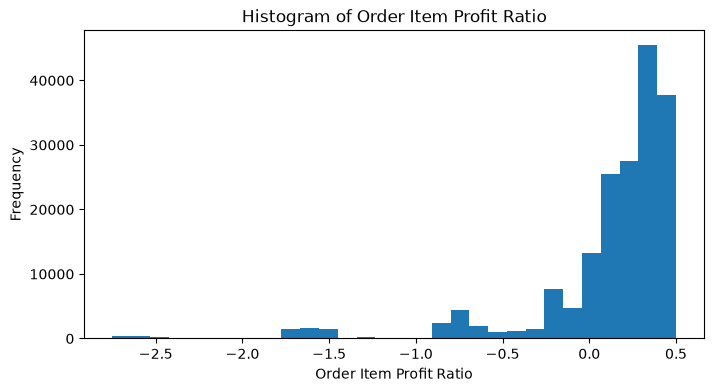

Histogram of Order Item Quantity


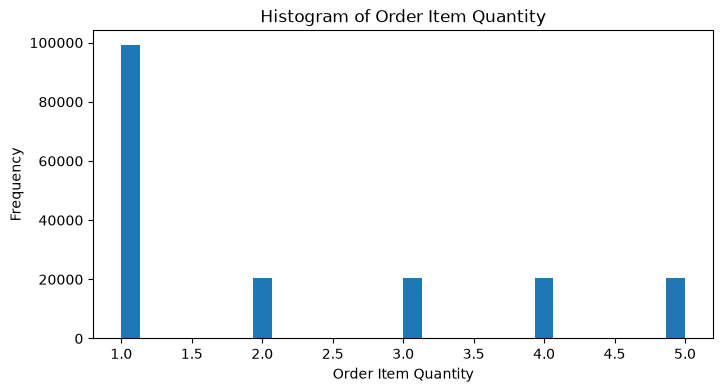

Histogram of Sales


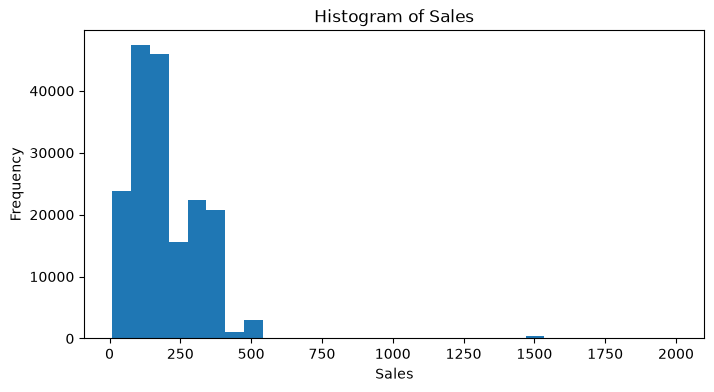

Histogram of Order Item Total


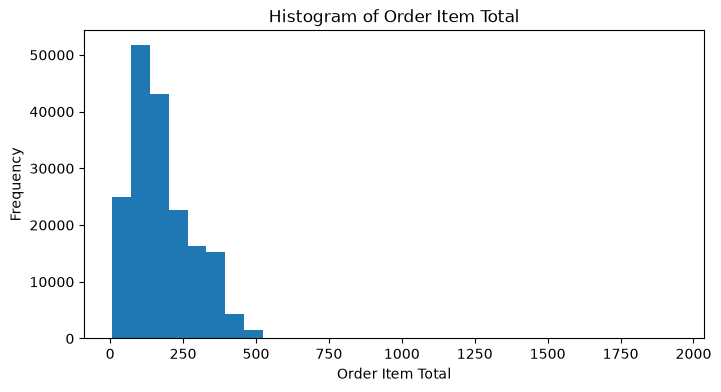

Histogram of Order Profit Per Order


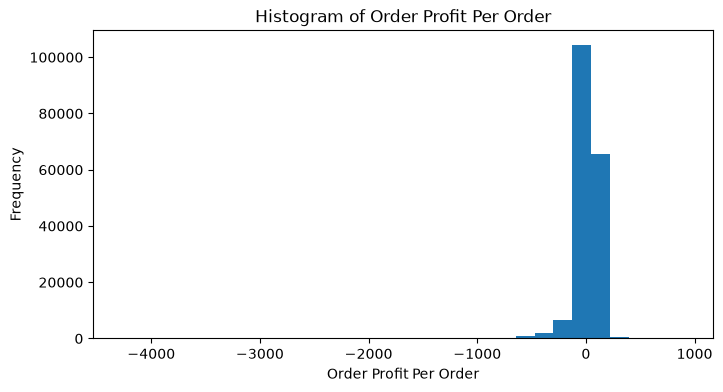

Histogram of Product Price


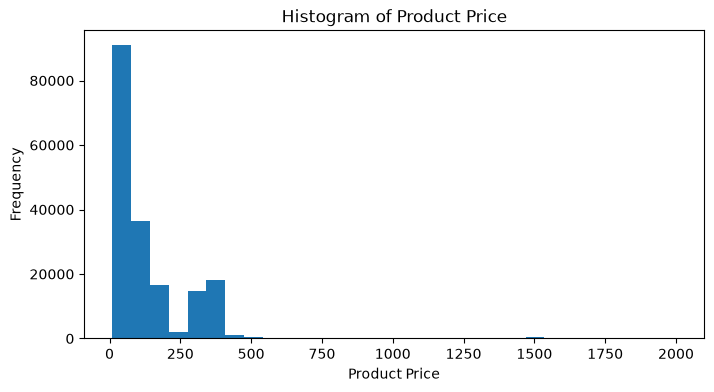

In [26]:
import matplotlib.pyplot as plt

numerical_columns = [
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Product Price",
    "Order Item Profit Ratio",
    "Order Item Quantity",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Product Price"
]

for col in numerical_columns:
    print("="*60)
    print(f"Histogram of {col}")
    print("="*60)

    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Count Plot of Category Name


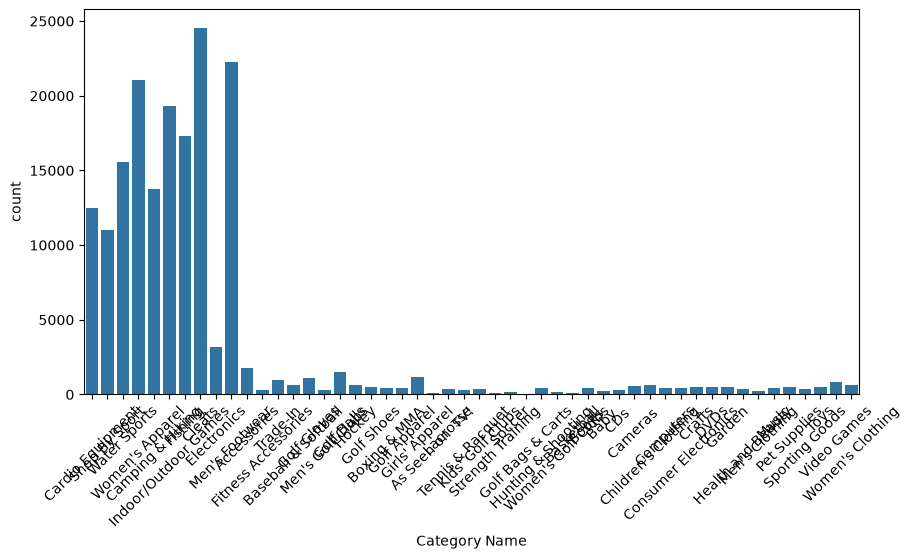

Count Plot of Customer Segment


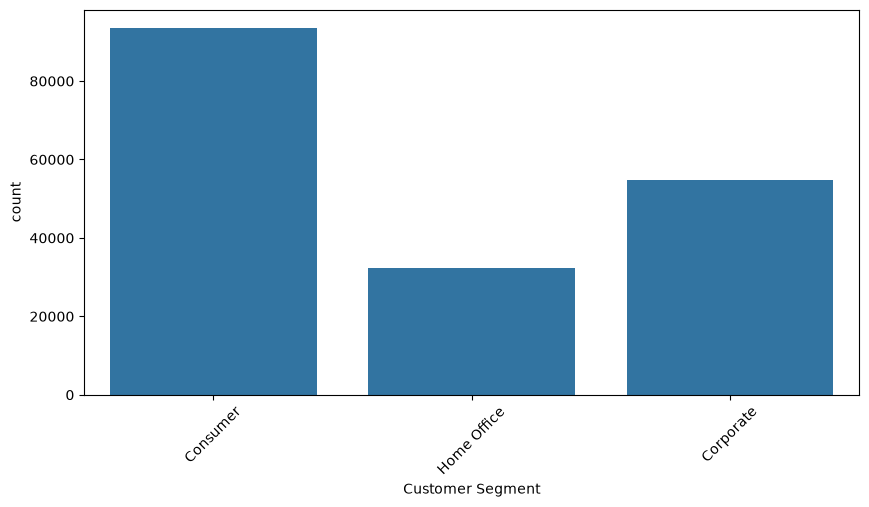

Count Plot of Department Name


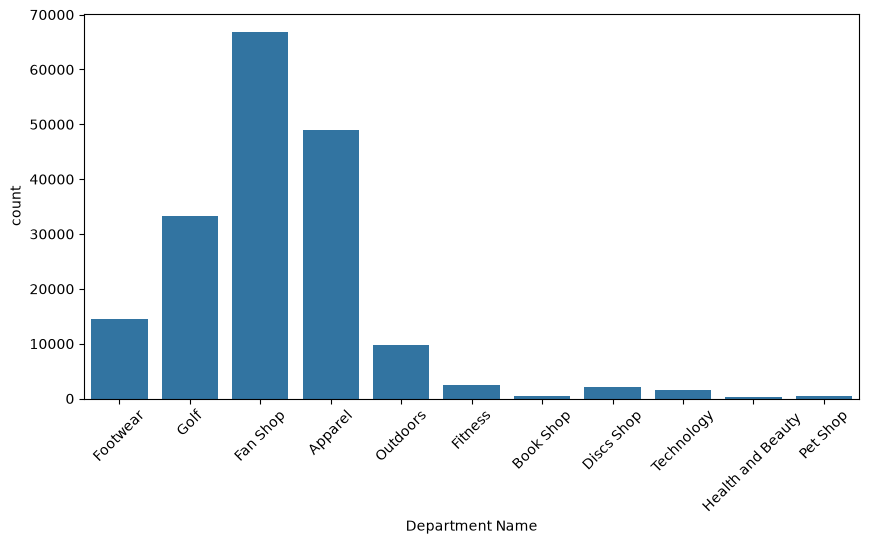

Count Plot of Market


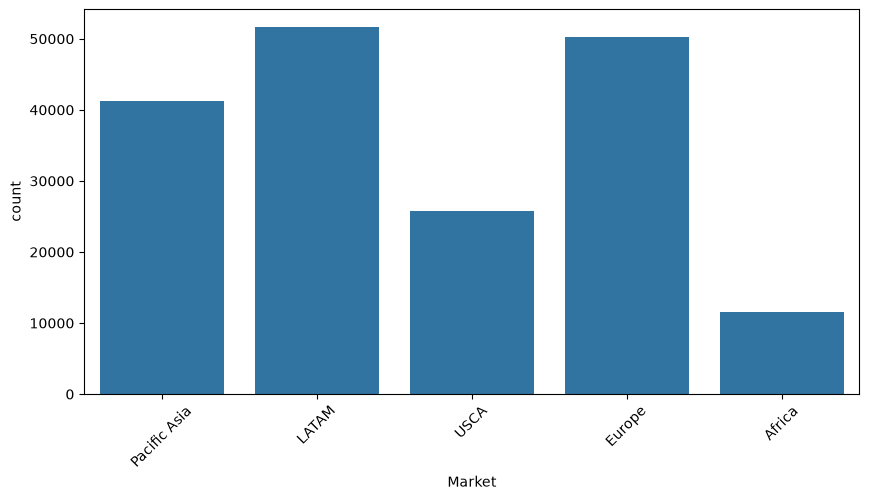

Count Plot of Order Status


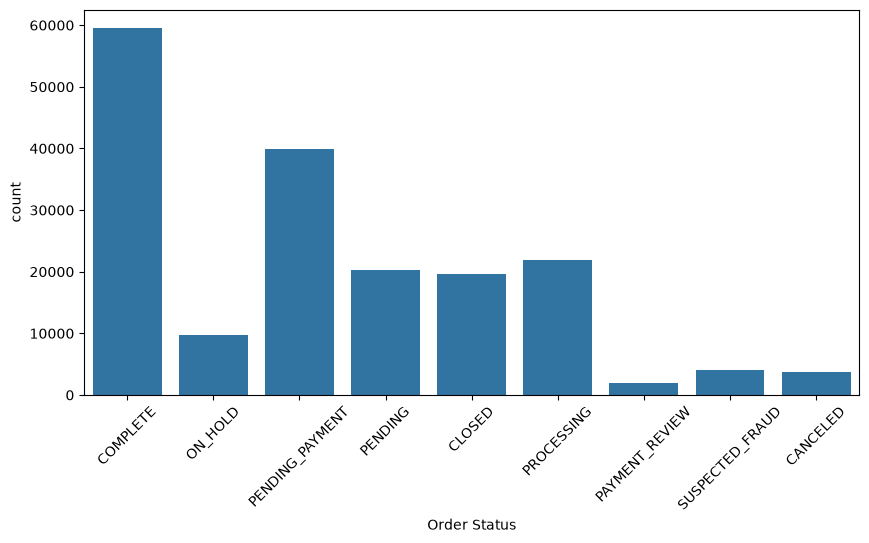

Count Plot of Shipping Mode


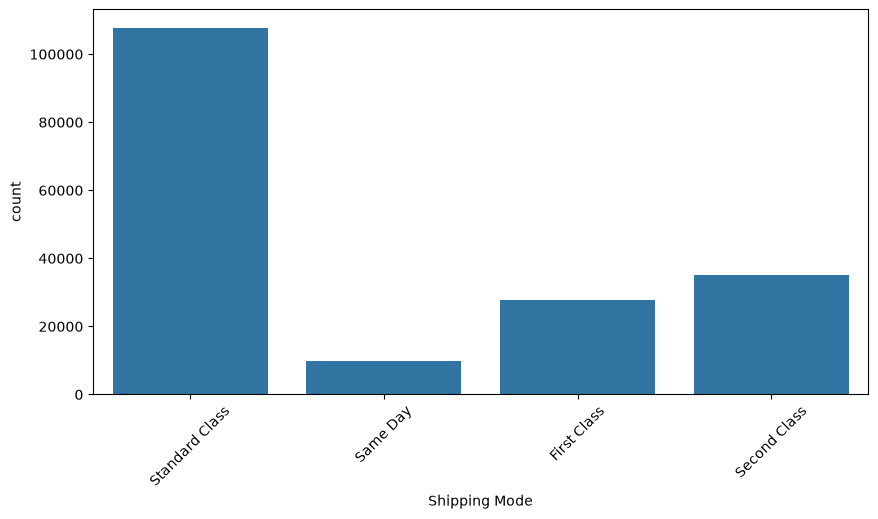

Count Plot of Delivery Status


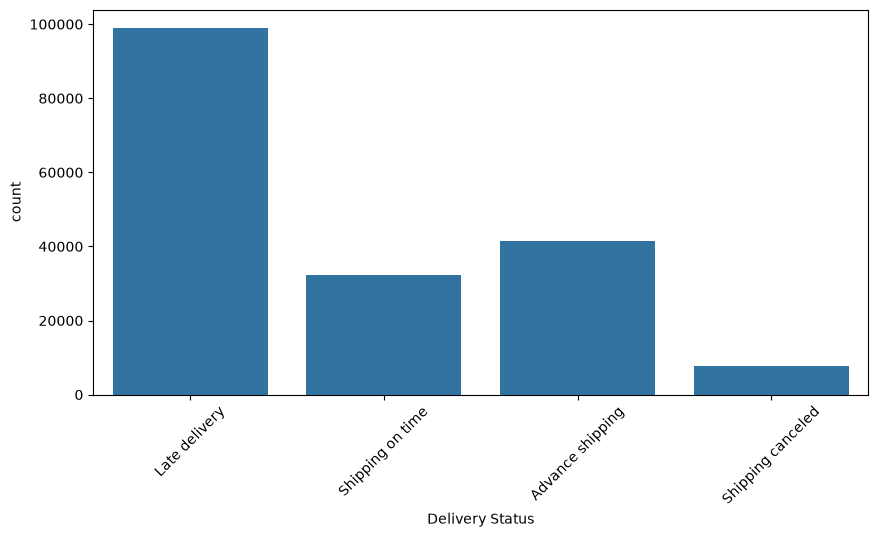

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_columns = [
    "Category Name",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Status",
    "Shipping Mode",
    "Delivery Status"
]

for col in categorical_columns:
    print("="*60)
    print(f"Count Plot of {col}")
    print("="*60)

    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

Scatter Plot: Sales vs Benefit per order


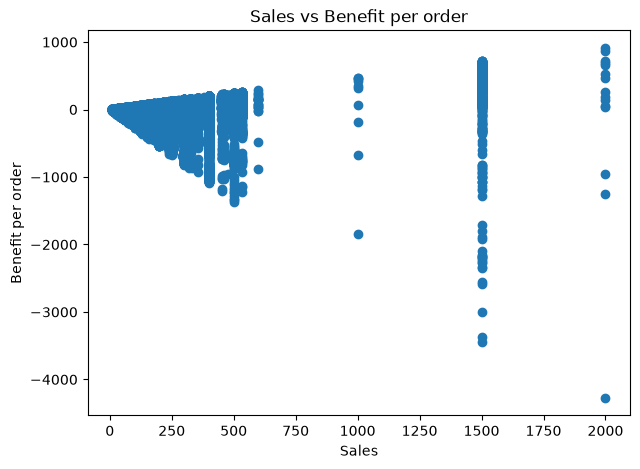

Scatter Plot: Sales vs Order Profit Per Order


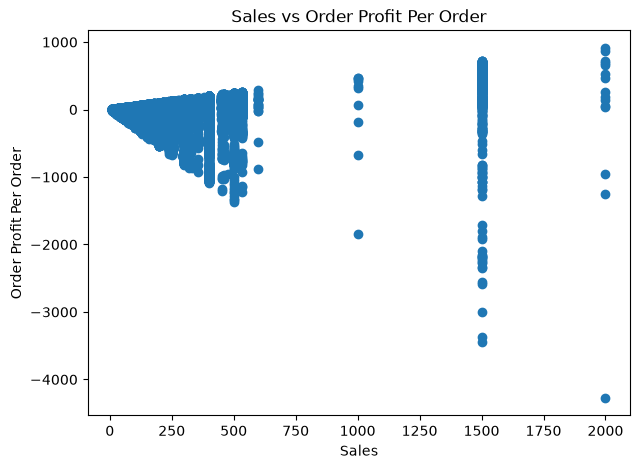

Scatter Plot: Order Item Discount vs Sales


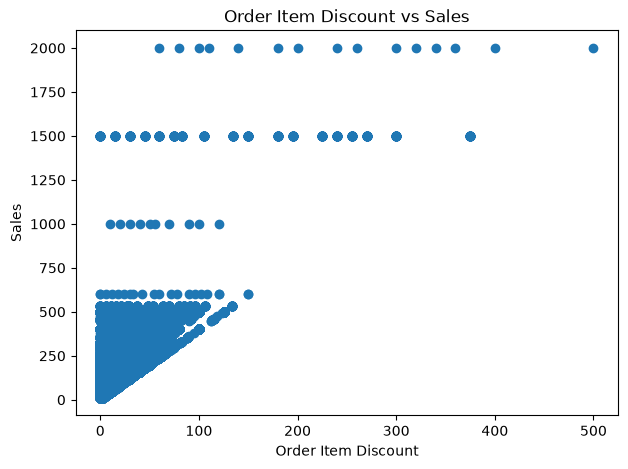

Scatter Plot: Product Price vs Sales


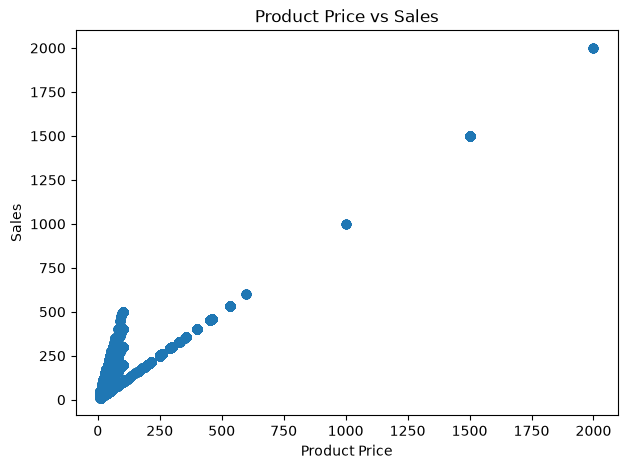

Scatter Plot: Order Item Quantity vs Sales


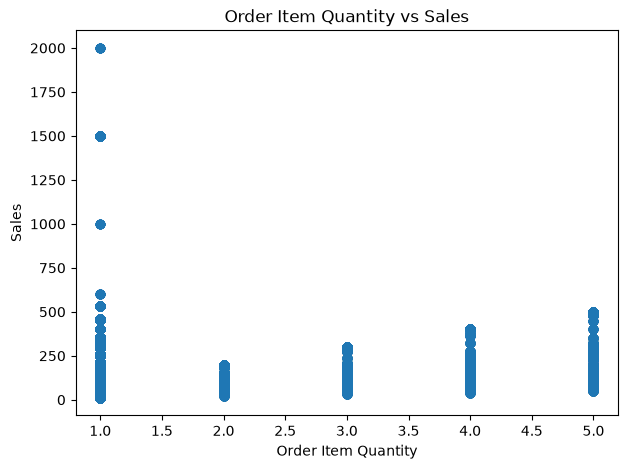

In [28]:
scatter_pairs = [
    ("Sales", "Benefit per order"),
    ("Sales", "Order Profit Per Order"),
    ("Order Item Discount", "Sales"),
    ("Product Price", "Sales"),
    ("Order Item Quantity", "Sales")
]

for x, y in scatter_pairs:

    print("="*60)
    print(f"Scatter Plot: {x} vs {y}")
    print("="*60)

    plt.figure(figsize=(7,5))
    plt.scatter(df[x], df[y])

    plt.xlabel(x)
    plt.ylabel(y)

    plt.title(f"{x} vs {y}")

    plt.show()

In [29]:
# Create a new DataFrame with Sales >= 1750
sales_750_df = df[df["Sales"] >= 1750]

# Display the DataFrame


pd.set_option('display.max_columns', None)

sales_750_df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
5217,TRANSFER,2,4,-952.56,1679.99,Advance shipping,0,10,Strength Training,Caguas,Puerto Rico,Mary,382,Lane,Consumer,PR,7666 High Dale Bank,3,Footwear,18.247520,-66.025269,Europe,Le Havre,Francia,382,320.0,0.16,1999.99,-0.57,1,1999.99,1679.99,-952.56,Western Europe,Normandía,PROCESSING,SOLE E35 Elliptical,1999.99,Standard Class
13617,DEBIT,4,4,-1246.09,1699.99,Shipping on time,0,10,Strength Training,Caguas,Puerto Rico,Catherine,986,Hawkins,Home Office,PR,3651 Rustic Cape,3,Footwear,18.227577,-66.044533,Europe,Milan,Italia,986,300.0,0.15,1999.99,-0.73,1,1999.99,1699.99,-1246.09,Southern Europe,Lombardía,COMPLETE,SOLE E35 Elliptical,1999.99,Standard Class
15793,DEBIT,5,4,721.60,1639.99,Late delivery,1,10,Strength Training,Augusta,EE. UU.,Mary,1148,Anderson,Consumer,GA,7213 Cozy Quay,3,Footwear,33.521042,-82.049355,Europe,Marseille,Francia,1148,360.0,0.18,1999.99,0.44,1,1999.99,1639.99,721.60,Western Europe,Provenza-Alpes-Costa Azul,COMPLETE,SOLE E35 Elliptical,1999.99,Standard Class
16778,DEBIT,3,4,473.20,1819.99,Advance shipping,0,10,Strength Training,Bronx,EE. UU.,Richard,1223,Perry,Consumer,NY,1655 Little Bear Circle,3,Footwear,40.838802,-73.870995,Europe,Rostock,Alemania,1223,180.0,0.09,1999.99,0.26,1,1999.99,1819.99,473.20,Western Europe,Mecklemburgo-Pomerania Occidental,COMPLETE,SOLE E35 Elliptical,1999.99,Standard Class
19518,DEBIT,5,2,-4274.98,1899.99,Late delivery,1,10,Strength Training,Frankfort,EE. UU.,Mary,1428,Clark,Consumer,KY,4311 Old Edge,3,Footwear,38.118618,-84.967422,Europe,Dudley,Reino Unido,1428,100.0,0.05,1999.99,-2.25,1,1999.99,1899.99,-4274.98,Northern Europe,Inglaterra,COMPLETE,SOLE E35 Elliptical,1999.99,Second Class
35671,DEBIT,2,2,864.00,1799.99,Shipping on time,0,10,Strength Training,Amarillo,EE. UU.,Phillip,2564,Smith,Corporate,TX,6068 Quaking Heath,3,Footwear,35.187542,-101.867622,Europe,Draguignan,Francia,2564,200.0,0.10,1999.99,0.48,1,1999.99,1799.99,864.00,Western Europe,Provenza-Alpes-Costa Azul,COMPLETE,SOLE E35 Elliptical,1999.99,Second Class
59044,DEBIT,3,4,520.00,1599.99,Advance shipping,0,10,Strength Training,San Diego,EE. UU.,Charles,4258,Rogers,Corporate,CA,2650 Rocky Stead,3,Footwear,32.760025,-117.248383,Europe,Chelmsford,Reino Unido,4258,400.0,0.20,1999.99,0.33,1,1999.99,1599.99,520.00,Northern Europe,Inglaterra,ON_HOLD,SOLE E35 Elliptical,1999.99,Standard Class
76906,DEBIT,2,1,911.80,1939.99,Late delivery,1,10,Strength Training,Caguas,Puerto Rico,Mary,5533,Harrison,Consumer,PR,852 Rocky Brook Mountain,3,Footwear,18.262022,-66.370590,Europe,Villenave-d'Ornon,Francia,5533,60.0,0.03,1999.99,0.47,1,1999.99,1939.99,911.80,Western Europe,Aquitania-Lemosín-Poitou-Charentes,COMPLETE,SOLE E35 Elliptical,1999.99,First Class
83124,DEBIT,5,4,660.00,1759.99,Late delivery,1,10,Strength Training,Caguas,Puerto Rico,Daniel,5946,Smith,Consumer,PR,4823 Golden Hollow,3,Footwear,18.237732,-66.370621,Europe,Genoa,Italia,5946,240.0,0.12,1999.99,0.38,1,1999.99,1759.99,660.00,Southern Europe,Liguria,ON_HOLD,SOLE E35 Elliptical,1999.99,Standard Class
91112,CASH,4,4,139.50,1859.99,Shipping on time,0,10,Strength Training,Caguas,Puerto Rico,Amber,6517,Sheppard,Consumer,PR,2963 Indian Elk Pathway,3,Footwear,18.208799,-66.370499,Europe,Toulouse,Francia,6517,140.0,0.07,1999.99,0.08,1,1999.99,1859.99,139.50,Western Europe,Languedoc-Rosellón-Mediodía-Pirineos,CLOSED,SOLE E35 Elliptical,1999.99,Standard Class


Number of records: 131586


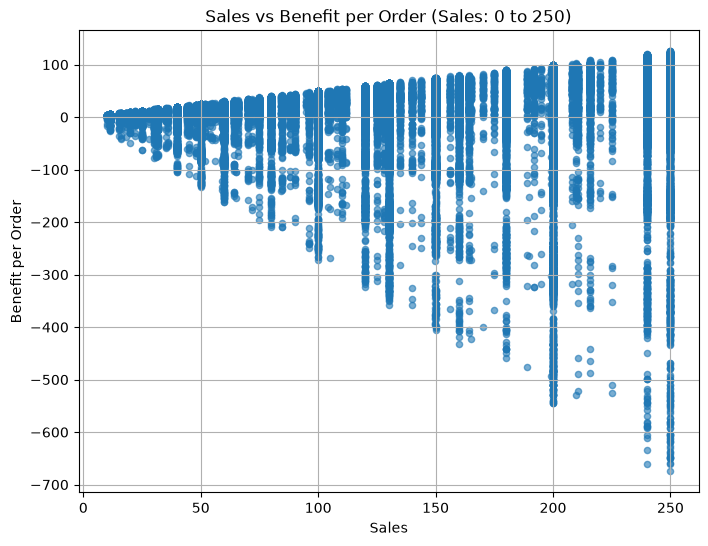

In [30]:
import matplotlib.pyplot as plt

# Filter data where Sales is between 0 and 250
sales_0_250_df = df[(df["Sales"] >= 0) & (df["Sales"] <= 250)]

print("Number of records:", len(sales_0_250_df))

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    sales_0_250_df["Sales"],
    sales_0_250_df["Benefit per order"],
    s=20,
    alpha=0.6
)

plt.title("Sales vs Benefit per Order (Sales: 0 to 250)")
plt.xlabel("Sales")
plt.ylabel("Benefit per Order")
plt.grid(True)

plt.show()

Number of records: 52186


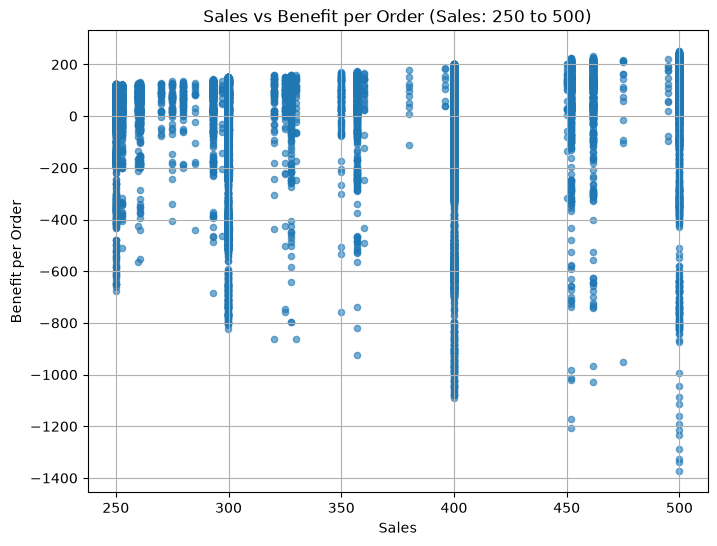

In [31]:
import matplotlib.pyplot as plt

# Filter data where Sales is between 250 and 500
sales_250_500_df = df[(df["Sales"] >= 250) & (df["Sales"] <= 500)]

print("Number of records:", len(sales_250_500_df))

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    sales_250_500_df["Sales"],
    sales_250_500_df["Benefit per order"],
    s=20,
    alpha=0.6
)

plt.title("Sales vs Benefit per Order (Sales: 250 to 500)")
plt.xlabel("Sales")
plt.ylabel("Benefit per Order")
plt.grid(True)

plt.show()

Number of records: 530


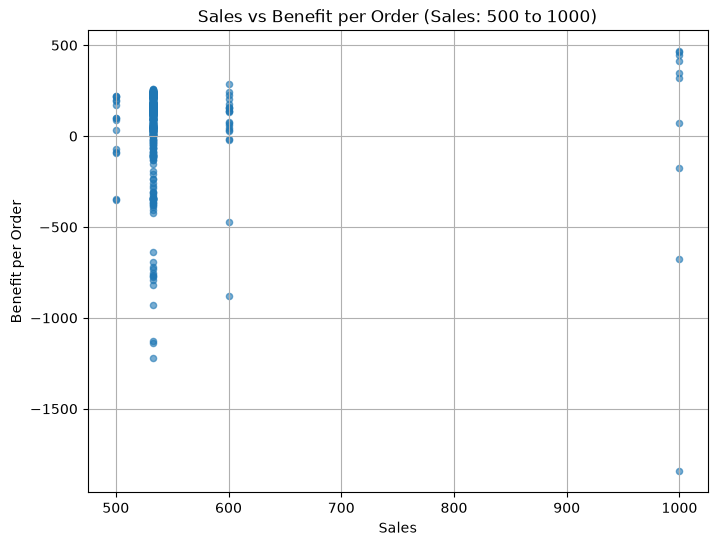

In [32]:
import matplotlib.pyplot as plt

# Filter data where Sales is between 500 and 1000
sales_500_1000_df = df[(df["Sales"] >= 500) & (df["Sales"] <= 1000)]

print("Number of records:", len(sales_500_1000_df))

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    sales_500_1000_df["Sales"],
    sales_500_1000_df["Benefit per order"],
    s=20,
    alpha=0.6
)

plt.title("Sales vs Benefit per Order (Sales: 500 to 1000)")
plt.xlabel("Sales")
plt.ylabel("Benefit per Order")
plt.grid(True)

plt.show()

Number of records: 457


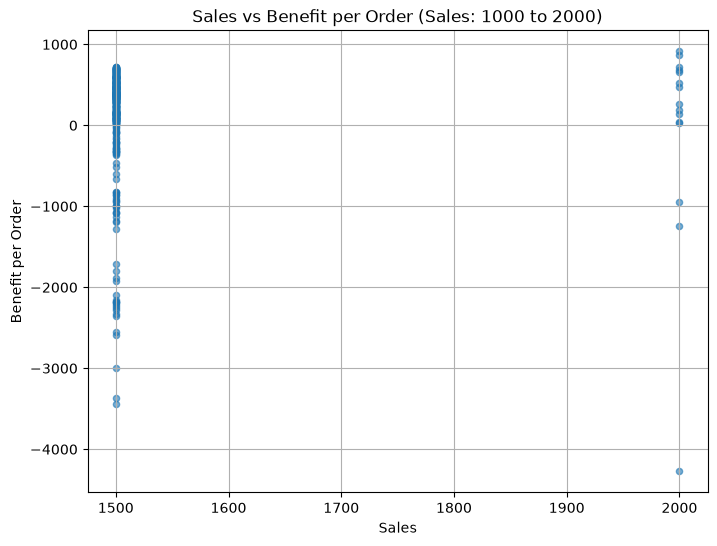

In [33]:
import matplotlib.pyplot as plt

# Filter data where Sales is between 1000 and 2000
sales_1000_2000_df = df[(df["Sales"] >= 1000) & (df["Sales"] <= 2000)]

print("Number of records:", len(sales_1000_2000_df))

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    sales_1000_2000_df["Sales"],
    sales_1000_2000_df["Benefit per order"],
    s=20,
    alpha=0.6
)

plt.title("Sales vs Benefit per Order (Sales: 1000 to 2000)")
plt.xlabel("Sales")
plt.ylabel("Benefit per Order")
plt.grid(True)

plt.show()

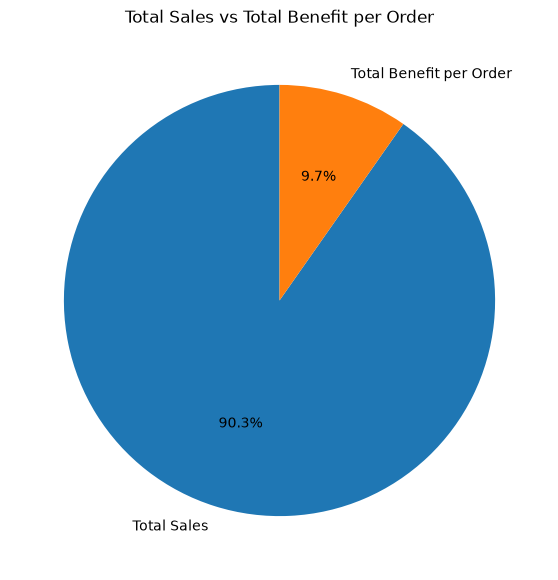

In [34]:
import matplotlib.pyplot as plt

# Total Sales and Total Benefit
values = [
    df["Sales"].sum(),
    df["Benefit per order"].sum()
]

labels = ["Total Sales", "Total Benefit per Order"]

plt.figure(figsize=(7,7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Total Sales vs Total Benefit per Order")

plt.show()

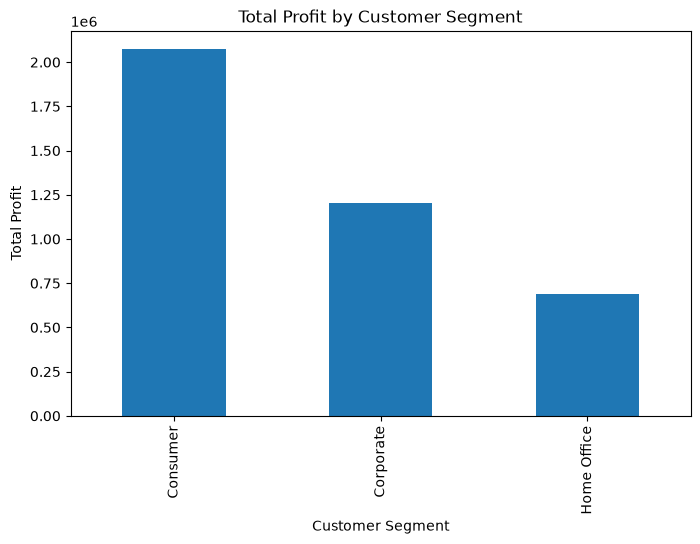

In [35]:
import matplotlib.pyplot as plt

profit_by_segment = df.groupby("Customer Segment")["Order Profit Per Order"].sum()

plt.figure(figsize=(8,5))
profit_by_segment.plot(kind="bar")

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.show()

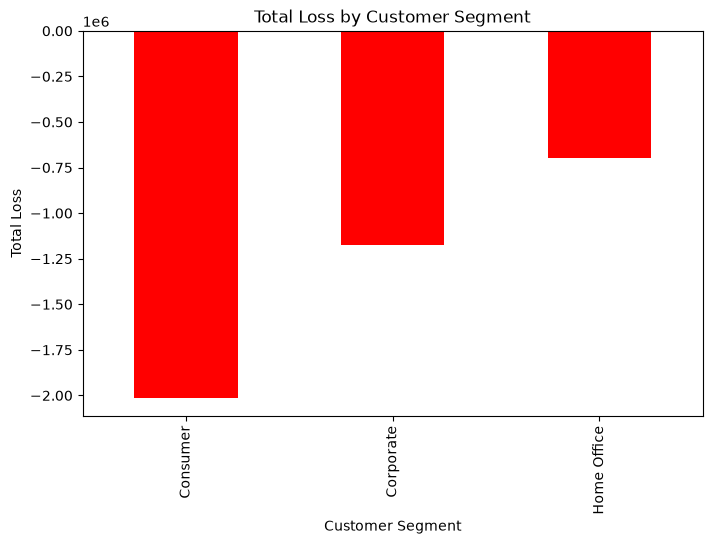

In [36]:
import matplotlib.pyplot as plt

# Filter only loss-making orders
loss_df = df[df["Order Profit Per Order"] < 0]

loss_by_segment = loss_df.groupby("Customer Segment")["Order Profit Per Order"].sum()

plt.figure(figsize=(8,5))
loss_by_segment.plot(kind="bar", color="red")

plt.title("Total Loss by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Loss")

plt.show()

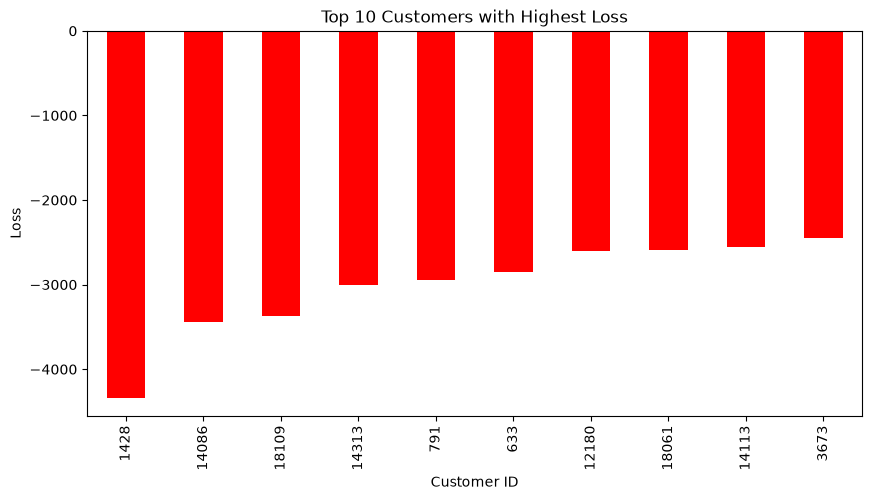

In [37]:
top_loss_customers = (
    loss_df.groupby("Customer Id")["Order Profit Per Order"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))
top_loss_customers.plot(kind="bar", color="red")

plt.title("Top 10 Customers with Highest Loss")
plt.xlabel("Customer ID")
plt.ylabel("Loss")

plt.show()

In [38]:
top_100_customers_df = (
    df.groupby(["Customer Id", "Customer Fname", "Customer Lname"])["Order Profit Per Order"]
      .sum()
      .reset_index()
      .sort_values(by="Order Profit Per Order", ascending=False)
      .head(30)
)

top_100_customers_df

,Customer Id,Customer Fname,Customer Lname,Order Profit Per Order
2612,2641,Betty,Spears,2441.97
1636,1657,Betty,Phillips,2196.92
9755,9833,Jacob,Smith,1938.39
2597,2626,Laura,Smith,1928.57
4958,5004,Dorothy,Friedman,1917.99
3697,3735,Mary,Lewis,1906.36
741,749,Jesse,Matthews,1855.15
5509,5560,Mary,Rodriguez,1831.46
10875,10967,Alexander,Cunningham,1822.33
5007,5053,Mary,Smith,1813.34


In [39]:
top_100_customers = (
    df.groupby("Customer Id")
      .agg({
          "Customer Fname": "first",
          "Customer Lname": "first",
          "Customer Segment": "first",
          "Customer City": "first",
          "Customer State": "first",
          "Customer Country": "first",
          "Customer Street": "first",
          "Market": "first",
          "Latitude": "first",
          "Longitude": "first",
          "Order Profit Per Order": "sum",
          "Sales": "sum",
          "Order Item Quantity": "sum"
      })
      .rename(columns={
          "Order Profit Per Order": "Total Profit",
          "Sales": "Total Sales",
          "Order Item Quantity": "Total Quantity"
      })
      .sort_values(by="Total Profit", ascending=False)
      .head(30)
      .reset_index()
)

top_100_customers

,Customer Id,Customer Fname,Customer Lname,Customer Segment,Customer City,Customer State,Customer Country,Customer Street,Market,Latitude,Longitude,Total Profit,Total Sales,Total Quantity
0,2641,Betty,Spears,Consumer,Carrollton,TX,EE. UU.,6398 Indian Brook Valley,USCA,32.965931,-96.849022,2441.97,9130.92,90
1,1657,Betty,Phillips,Consumer,Caguas,PR,Puerto Rico,1475 Red Berry Village,USCA,18.244795,-66.370506,2196.92,9223.71,111
2,9833,Jacob,Smith,Consumer,Caguas,PR,Puerto Rico,1043 Golden Timber Impasse,Europe,18.237686,-66.370514,1938.39,6059.38,48
3,2626,Laura,Smith,Consumer,Oceanside,CA,EE. UU.,4791 Sunny Downs,Africa,33.216427,-117.270653,1928.57,6274.36,55
4,5004,Dorothy,Friedman,Home Office,Miami,FL,EE. UU.,6461 Silver Heath,LATAM,25.584570,-80.373611,1917.99,8164.70,114
5,3735,Mary,Lewis,Corporate,El Centro,CA,EE. UU.,3569 Red Dell,USCA,32.792953,-115.558807,1906.36,6019.33,61
6,749,Jesse,Matthews,Consumer,Caguas,PR,Puerto Rico,529 Cotton Branch Grove,Africa,18.227573,-66.043991,1855.15,7649.38,64
7,5560,Mary,Rodriguez,Corporate,Caguas,PR,Puerto Rico,4687 Stony Goose Crossing,LATAM,18.210855,-66.370636,1831.46,6528.21,74
8,10967,Alexander,Cunningham,Consumer,Caguas,PR,Puerto Rico,7373 Pleasant Estates,Pacific Asia,18.215086,-66.370560,1822.33,5734.41,64
9,5053,Mary,Smith,Corporate,Caguas,PR,Puerto Rico,870 Amber Quail Circuit,Europe,18.223675,-66.370522,1813.34,7411.32,67


In [40]:
# Top 5 Most Sold Products
top_5_products = (
    df.groupby("Product Name")["Order Item Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print(top_5_products)

Product Name
Perfect Fitness Perfect Rip Deck                 73698
Nike Men's Dri-FIT Victory Golf Polo             62956
O'Brien Men's Neoprene Life Vest                 57803
Nike Men's Free 5.0+ Running Shoe                36680
Under Armour Girls' Toddler Spine Surge Runni    31735
Name: Order Item Quantity, dtype: int64


In [41]:
overall_loss_products = (
    df.groupby("Product Name")
      .agg(
          Total_Loss=("Order Profit Per Order", "sum"),
          Total_Orders=("Product Name", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Quantity=("Order Item Quantity", "sum")
      )
      .reset_index()
)

overall_loss_products = overall_loss_products[
    overall_loss_products["Total_Loss"] < 0
]

overall_loss_products = overall_loss_products.sort_values(
    by="Total_Loss",
    ascending=True
)

overall_loss_products

,Product Name,Total_Loss,Total_Orders,Total_Sales,Total_Quantity
77,SOLE E35 Elliptical,-965.12,15,29999.85,15
9,Bushnell Pro X7 Jolt Slope Rangefinder,-255.95,11,6599.89,11
76,SOLE E25 Elliptical,-169.56,10,9999.90,10


In [42]:
# Separate profitable and loss-making orders
profit_orders = df[df["Order Profit Per Order"] > 0]
loss_orders = df[df["Order Profit Per Order"] < 0]

# Calculate totals
total_profit = profit_orders["Order Profit Per Order"].sum()
total_loss = loss_orders["Order Profit Per Order"].sum()   # Negative value
net_profit = df["Order Profit Per Order"].sum()

print("Total Profit :", round(total_profit, 2))
print("Total Loss   :", round(total_loss, 2))
print("Net Profit   :", round(net_profit, 2))

Total Profit : 7850450.32
Total Loss   : -3883547.35
Net Profit   : 3966902.97


In [43]:
# Total Profit (positive values only)
total_profit = df[df["Order Profit Per Order"] > 0]["Order Profit Per Order"].sum()

# Total Loss (convert to positive)
total_loss = abs(df[df["Order Profit Per Order"] < 0]["Order Profit Per Order"].sum())

# Profit-to-Loss Ratio
ratio = total_profit / total_loss

print(f"Total Profit : {total_profit:.2f}")
print(f"Total Loss   : {total_loss:.2f}")
print(f"Profit : Loss Ratio = {ratio:.2f} : 1")

Total Profit : 7850450.32
Total Loss   : 3883547.35
Profit : Loss Ratio = 2.02 : 1


In [44]:
# Product-wise Quantity Sold and Total Profit
least_bought_loss_products = (
    df.groupby("Product Name")
      .agg(
          Total_Quantity=("Order Item Quantity", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
)

# Keep only products with overall loss
least_bought_loss_products = least_bought_loss_products[
    least_bought_loss_products["Total_Profit"] < 0
]

# Sort by least quantity sold
least_bought_loss_products = least_bought_loss_products.sort_values(
    by=["Total_Quantity", "Total_Profit"],
    ascending=[True, True]
)

least_bought_loss_products

,Product Name,Total_Quantity,Total_Profit,Total_Sales
76,SOLE E25 Elliptical,10,-169.56,9999.90
9,Bushnell Pro X7 Jolt Slope Rangefinder,11,-255.95,6599.89
77,SOLE E35 Elliptical,15,-965.12,29999.85


In [45]:
# Products that have at least one loss-making order
products_with_loss = (
    df[df["Order Profit Per Order"] < 0]["Product Name"]
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)

products_with_loss

0                                 Adult dog supplies
1                                       Baby sweater
2                            Bag Boy Beverage Holder
3                             Bag Boy M330 Push Cart
4                  Bowflex SelectTech 1090 Dumbbells
                           ...                      
113            adidas Kids' F5 Messi FG Soccer Cleat
114       adidas Men's F10 Messi TRX FG Soccer Cleat
115        adidas Men's Germany Black Crest Away Tee
116    adidas Youth Germany Black/Red Away Match Soc
117                 insta-bed Neverflat Air Mattress
Name: Product Name, Length: 118, dtype: str

In [46]:
# Total unique products
total_products = df["Product Name"].nunique()

print("Total Products:", total_products)

Total Products: 118


In [47]:
# Hero Product Analysis
hero_products = (
    df.groupby("Product Name")
      .apply(lambda x: pd.Series({
          "Times Sold": len(x),
          "Total Quantity Sold": x["Order Item Quantity"].sum(),
          "Loss Count": (x["Order Profit Per Order"] < 0).sum(),
          "Total Loss": abs(
              x.loc[x["Order Profit Per Order"] < 0,
                    "Order Profit Per Order"].sum()
          ),
          "Total Profit": x.loc[
              x["Order Profit Per Order"] > 0,
              "Order Profit Per Order"
          ].sum(),
          "Net Profit": x["Order Profit Per Order"].sum(),
          "Total Sales Value": x["Sales"].sum()
      }))
      .reset_index()
)

# Keep only profitable products
hero_products = hero_products[
    hero_products["Net Profit"] > 0
]

# Sort by:
# 1. Highest Net Profit
# 2. Lowest Loss Count
# 3. Highest Times Sold
hero_products = hero_products.sort_values(
    by=["Net Profit", "Loss Count", "Times Sold"],
    ascending=[False, True, False]
)

# Top 10 Hero Products
top_10_hero_products = hero_products.head(10)

top_10_hero_products

,Product Name,Times Sold,Total Quantity Sold,Loss Count,Total Loss,Total Profit,Net Profit,Total Sales Value
24,Field & Stream Sportsman 16 Gun Fire Safe,17325.0,17325.0,3209.0,728570.95,1484791.71,756220.76,6929653.50
71,Perfect Fitness Perfect Rip Deck,24515.0,73698.0,4583.0,450978.29,944806.59,493828.30,4421143.02
21,Diamondback Women's Serene Classic Comfort Bi,13729.0,13729.0,2590.0,443082.23,870537.80,427455.57,4118425.42
61,Nike Men's Free 5.0+ Running Shoe,12169.0,36680.0,2271.0,400015.04,779930.86,379915.82,3667633.20
59,Nike Men's Dri-FIT Victory Golf Polo,21035.0,62956.0,3923.0,323772.87,674193.90,350421.03,3147800.00
70,Pelican Sunstream 100 Kayak,15500.0,15500.0,2916.0,332804.25,656880.62,324076.37,3099845.00
67,O'Brien Men's Neoprene Life Vest,19298.0,57803.0,3617.0,298637.48,617088.91,318451.43,2888993.94
56,Nike Men's CJ Elite 2 TD Football Cleat,22246.0,22246.0,4169.0,309269.70,621172.52,311902.82,2891757.54
102,Under Armour Girls' Toddler Spine Surge Runni,10617.0,31735.0,2085.0,139661.49,265940.00,126278.51,1269082.65
18,Dell Laptop,442.0,442.0,73.0,74967.13,144623.94,69656.81,663000.00


In [48]:
# Top 10 Most Sold Products

top_10_sold_products = (
    df.groupby("Product Name")
      .agg(
          Times_Sold=("Product Name", "count"),
          Total_Quantity_Sold=("Order Item Quantity", "sum"),
          Total_Sales_Value=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum")
      )
      .sort_values(by="Total_Quantity_Sold", ascending=False)
      .head(10)
      .reset_index()
)

top_10_sold_products

,Product Name,Times_Sold,Total_Quantity_Sold,Total_Sales_Value,Total_Profit
0,Perfect Fitness Perfect Rip Deck,24515,73698,4421143.02,493828.30
1,Nike Men's Dri-FIT Victory Golf Polo,21035,62956,3147800.00,350421.03
2,O'Brien Men's Neoprene Life Vest,19298,57803,2888993.94,318451.43
3,Nike Men's Free 5.0+ Running Shoe,12169,36680,3667633.20,379915.82
4,Under Armour Girls' Toddler Spine Surge Runni,10617,31735,1269082.65,126278.51
5,Nike Men's CJ Elite 2 TD Football Cleat,22246,22246,2891757.54,311902.82
6,Field & Stream Sportsman 16 Gun Fire Safe,17325,17325,6929653.50,756220.76
7,Pelican Sunstream 100 Kayak,15500,15500,3099845.00,324076.37
8,Diamondback Women's Serene Classic Comfort Bi,13729,13729,4118425.42,427455.57
9,ENO Atlas Hammock Straps,323,998,29930.02,2139.58


In [49]:
country_summary = (
    df.groupby("Order Country")
      .agg(
          Total_Orders=("Order Country", "count"),
          Total_Customers=("Customer Id", "nunique"),
          Total_Quantity_Sold=("Order Item Quantity", "sum"),
          Total_Sales=("Sales", "sum"),

          Total_Profit=("Order Profit Per Order",
                        lambda x: x[x > 0].sum()),

          Total_Loss=("Order Profit Per Order",
                      lambda x: abs(x[x < 0].sum())),

          Net_Profit=("Order Profit Per Order", "sum"),

          Loss_Count=("Order Profit Per Order",
                      lambda x: (x < 0).sum()),

          Avg_Order_Value=("Sales", "mean")
      )
      .reset_index()
)

country_summary["Profit_Loss_Ratio"] = (
    country_summary["Total_Profit"] /
    country_summary["Total_Loss"].replace(0, 1)
).round(2)

country_summary = country_summary.sort_values(
    by="Net_Profit",
    ascending=False
)

country_summary

,Order Country,Total_Orders,Total_Customers,Total_Quantity_Sold,Total_Sales,Total_Profit,Total_Loss,Net_Profit,Loss_Count,Avg_Order_Value,Profit_Loss_Ratio
48,Estados Unidos,24840,6102,54433,4879667.57,1052541.11,512128.04,540413.07,4649,196.443944,2.06
53,Francia,13222,4245,27676,2879942.31,618859.21,291030.63,327828.58,2391,217.814424,2.13
102,México,13172,3706,28794,2633195.24,565990.09,262711.72,303278.37,2341,199.908536,2.15
2,Alemania,9564,3188,19803,2074171.78,438602.41,243775.33,194827.08,1928,216.872834,1.80
20,Brasil,7987,2399,17405,1594319.92,344953.32,158239.68,186713.64,1465,199.614363,2.18
...,...,...,...,...,...,...,...,...,...,...,...
98,Mongolia,79,28,185,15481.74,2472.36,2758.59,-286.23,24,195.971392,0.90
18,Bosnia y Herzegovina,45,16,83,8869.09,1443.53,1770.91,-327.38,15,197.090889,0.82
127,Ruanda,86,30,185,18913.02,3890.71,4220.73,-330.02,18,219.918837,0.92
146,Taiwán,29,13,52,6396.33,1066.62,2441.16,-1374.54,11,220.563103,0.44


In [50]:
# Top 10 Countries by Net Profit

top_10_countries = (
    df.groupby("Order Country")
      .agg(
          Total_Customers=("Customer Id", "nunique"),
          Total_Orders=("Order Country", "count"),
          Total_Quantity_Sold=("Order Item Quantity", "sum"),
          Total_Sales=("Sales", "sum"),

          Total_Profit=("Order Profit Per Order",
                        lambda x: x[x > 0].sum()),

          Total_Loss=("Order Profit Per Order",
                      lambda x: abs(x[x < 0].sum())),

          Net_Profit=("Order Profit Per Order", "sum"),

          Loss_Count=("Order Profit Per Order",
                      lambda x: (x < 0).sum())
      )
      .sort_values(by="Net_Profit", ascending=False)
      .head(10)
      .reset_index()
)

top_10_countries

,Order Country,Total_Customers,Total_Orders,Total_Quantity_Sold,Total_Sales,Total_Profit,Total_Loss,Net_Profit,Loss_Count
0,Estados Unidos,6102,24840,54433,4879667.57,1052541.11,512128.04,540413.07,4649
1,Francia,4245,13222,27676,2879942.31,618859.21,291030.63,327828.58,2391
2,México,3706,13172,28794,2633195.24,565990.09,262711.72,303278.37,2341
3,Alemania,3188,9564,19803,2074171.78,438602.41,243775.33,194827.08,1928
4,Brasil,2399,7987,17405,1594319.92,344953.32,158239.68,186713.64,1465
5,Reino Unido,2582,7302,15214,1612094.82,345307.70,164364.82,180942.88,1347
6,Australia,3586,8497,16766,1694621.64,360554.56,190512.98,170041.58,1613
7,China,2529,5758,11448,1172902.09,247547.08,125356.16,122190.92,1071
8,Italia,1785,4989,10218,1072181.65,230535.43,108989.96,121545.47,912
9,India,2094,4783,9539,962396.68,202379.81,102632.99,99746.82,921


In [51]:
# Top 10 Products
top_products = (
    df.groupby("Product Name")["Order Item Quantity"]
      .sum()
      .nlargest(10)
      .index
)

# Top 10 Countries
top_countries = (
    df.groupby("Order Country")["Sales"]
      .sum()
      .nlargest(10)
      .index
)

comparison_df = df[
    (df["Product Name"].isin(top_products)) &
    (df["Order Country"].isin(top_countries))
]

comparison = (
    comparison_df.pivot_table(
        index="Order Country",
        columns="Product Name",
        values="Order Item Quantity",
        aggfunc="sum",
        fill_value=0
    )
)

comparison

Product Name,Diamondback Women's Serene Classic Comfort Bi,ENO Atlas Hammock Straps,Field & Stream Sportsman 16 Gun Fire Safe,Nike Men's CJ Elite 2 TD Football Cleat,Nike Men's Dri-FIT Victory Golf Polo,Nike Men's Free 5.0+ Running Shoe,O'Brien Men's Neoprene Life Vest,Pelican Sunstream 100 Kayak,Perfect Fitness Perfect Rip Deck,Under Armour Girls' Toddler Spine Surge Runni
Order Country,,,,,,,,,,
Alemania,742,30,911,1155,3293,2010,2842,814,3778,1656
Australia,558,54,742,942,2449,1622,2379,637,2926,1207
Brasil,673,31,801,1002,3093,1652,2668,711,3225,1481
China,351,47,487,642,1619,1018,1682,409,1918,865
Estados Unidos,1973,156,2499,3267,9210,5060,8058,2228,10818,4555
Francia,962,50,1269,1544,4635,2671,4077,1136,5383,2547
India,324,20,400,508,1427,760,1256,341,1621,796
Italia,360,18,472,632,1679,934,1568,455,1910,802
México,1088,82,1323,1728,4753,2701,4551,1207,5626,2508


In [52]:
correlation = df[["Order Item Discount", "Order Item Profit Ratio"]].corr()

print(correlation)

                         Order Item Discount  Order Item Profit Ratio
Order Item Discount                 1.000000                -0.002788
Order Item Profit Ratio            -0.002788                 1.000000


In [53]:
# Create Discount Groups
df["Discount Range"] = pd.cut(
    df["Order Item Discount"],
    bins=[0,50,100,200,500,1000,2000],
    labels=[
        "0-50",
        "51-100",
        "101-200",
        "201-500",
        "501-1000",
        "1000+"
    ]
)

discount_analysis = (
    df.groupby("Discount Range")
      .agg(
          Average_Profit_Margin=("Order Item Profit Ratio","mean"),
          Average_Profit=("Order Profit Per Order","mean"),
          Average_Sales=("Sales","mean"),
          Orders=("Order Item Discount","count")
      )
)

discount_analysis

,Average_Profit_Margin,Average_Profit,Average_Sales,Orders
Discount Range,,,,
0-50,0.120307,19.954929,183.635143,154289
51-100,0.119612,35.937969,373.487610,15655
101-200,0.117995,83.626118,826.566015,389
201-500,0.129241,161.551139,1525.315949,158


In [54]:
# Top 30 Customers with Most Orders

top_30_customers = (
    df.groupby("Customer Id")
      .agg(
          Customer_Fname=("Customer Fname", "first"),
          Customer_Lname=("Customer Lname", "first"),
          Customer_Segment=("Customer Segment", "first"),
          Customer_City=("Customer City", "first"),
          Customer_State=("Customer State", "first"),
          Customer_Country=("Customer Country", "first"),

          Total_Orders=("Customer Id", "count"),
          Total_Quantity=("Order Item Quantity", "sum"),
          Total_Sales=("Sales", "sum"),

          Total_Profit=("Order Profit Per Order",
                        lambda x: x[x > 0].sum()),

          Total_Loss=("Order Profit Per Order",
                      lambda x: abs(x[x < 0].sum())),

          Net_Profit=("Order Profit Per Order", "sum"),

          Avg_Order_Value=("Sales", "mean")
      )
      .sort_values(by="Total_Orders", ascending=False)
      .head(30)
      .reset_index()
)

top_30_customers

,Customer Id,Customer_Fname,Customer_Lname,Customer_Segment,Customer_City,Customer_State,Customer_Country,Total_Orders,Total_Quantity,Total_Sales,Total_Profit,Total_Loss,Net_Profit,Avg_Order_Value
0,5654,Jerry,Smith,Home Office,Caguas,PR,Puerto Rico,47,103,8904.95,1821.78,776.42,1045.36,189.467021
1,5004,Dorothy,Friedman,Home Office,Miami,FL,EE. UU.,45,114,8164.70,2243.21,325.22,1917.99,181.437778
2,10591,Deborah,Humphrey,Corporate,Plymouth,MA,EE. UU.,45,99,7889.05,2030.08,331.49,1698.59,175.312222
3,9371,Mary,Patterson,Consumer,Meridian,ID,EE. UU.,44,87,9299.03,1984.73,638.15,1346.58,211.341591
4,3708,Judy,Miller,Consumer,Westerville,OH,EE. UU.,44,82,8275.09,2256.64,603.90,1652.74,188.070227
5,5715,Kelly,Smith,Corporate,Caguas,PR,Puerto Rico,44,99,8595.13,1419.51,1596.96,-177.45,195.343864
6,1443,Denise,Cohen,Consumer,West Orange,NJ,EE. UU.,43,86,8150.13,1923.13,539.33,1383.80,189.537907
7,12284,Mary,Smith,Consumer,New Haven,CT,EE. UU.,43,110,8258.62,1769.56,307.10,1462.46,192.060930
8,2641,Betty,Spears,Consumer,Carrollton,TX,EE. UU.,43,90,9130.92,2547.00,105.03,2441.97,212.346977
9,791,Mary,Smith,Corporate,Canton,MI,EE. UU.,43,82,10524.17,2074.59,2940.97,-866.38,244.748140


In [55]:
# Sales if no discount had been given
df["Sales Without Discount"] = df["Sales"] + df["Order Item Discount"]

df[["Sales", "Order Item Discount", "Sales Without Discount"]].head()

,Sales,Order Item Discount,Sales Without Discount
0,499.95,27.50,527.45
1,199.95,31.99,231.94
2,199.99,18.00,217.99
3,199.99,24.00,223.99
4,50.00,10.00,60.00


In [56]:
total_sales_without_discount = df["Sales Without Discount"].sum()

print("Total Sales Without Discount:", total_sales_without_discount)

Total Sales Without Discount: 40515112.71


In [57]:
total_discount = df["Order Item Discount"].sum()

print("Total Discount Given:", total_discount)

Total Discount Given: 3730378.4


In [58]:
df["Estimated Profit Without Discount"] = (
    df["Order Profit Per Order"] + df["Order Item Discount"]
)

estimated_profit = df["Estimated Profit Without Discount"].sum()

print("Estimated Profit Without Discount:", estimated_profit)

Estimated Profit Without Discount: 7697281.37


In [59]:
comparison = pd.DataFrame({
    "Current": [
        df["Sales"].sum(),
        df["Order Profit Per Order"].sum()
    ],
    "Without Discount": [
        df["Sales Without Discount"].sum(),
        df["Estimated Profit Without Discount"].sum()
    ]
}, index=["Total Sales", "Estimated Net Profit"])

comparison

,Current,Without Discount
Total Sales,36784734.31,40515112.71
Estimated Net Profit,3966902.97,7697281.37


In [60]:
# Create discount percentage buckets
df["Discount Bucket"] = pd.cut(
    df["Order Item Discount Rate"],
    bins=[0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.50, 1.00],
    labels=[
        "0-5%",
        "5-10%",
        "10-15%",
        "15-20%",
        "20-25%",
        "25-50%",
        "50%+"
    ],
    include_lowest=True
)

In [61]:
discount_threshold = (
    df.groupby("Discount Bucket")
      .agg(
          Orders=("Order Item Discount Rate", "count"),
          Avg_Discount=("Order Item Discount Rate", "mean"),
          Avg_Profit_Margin=("Order Item Profit Ratio", "mean"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Sales=("Sales", "mean")
      )
      .reset_index()
)

discount_threshold

,Discount Bucket,Orders,Avg_Discount,Avg_Profit_Margin,Avg_Profit,Total_Profit,Avg_Sales
0,0-5%,60171,0.025001,0.122081,23.916745,1439094.48,203.721307
1,5-10%,40116,0.080000,0.122668,23.095813,926511.63,203.755412
2,10-15%,30087,0.133333,0.117898,20.784363,625339.12,203.801887
3,15-20%,40116,0.177500,0.116907,19.544845,784061.02,203.825350
4,20-25%,10029,0.250000,0.127158,19.134183,191896.72,203.841095


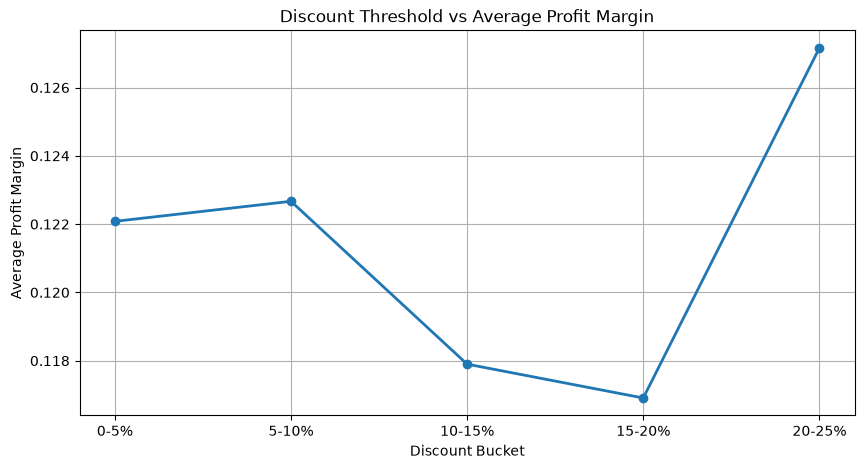

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    discount_threshold["Discount Bucket"],
    discount_threshold["Avg_Profit_Margin"],
    marker="o",
    linewidth=2
)

plt.title("Discount Threshold vs Average Profit Margin")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Profit Margin")

plt.grid(True)

plt.show()

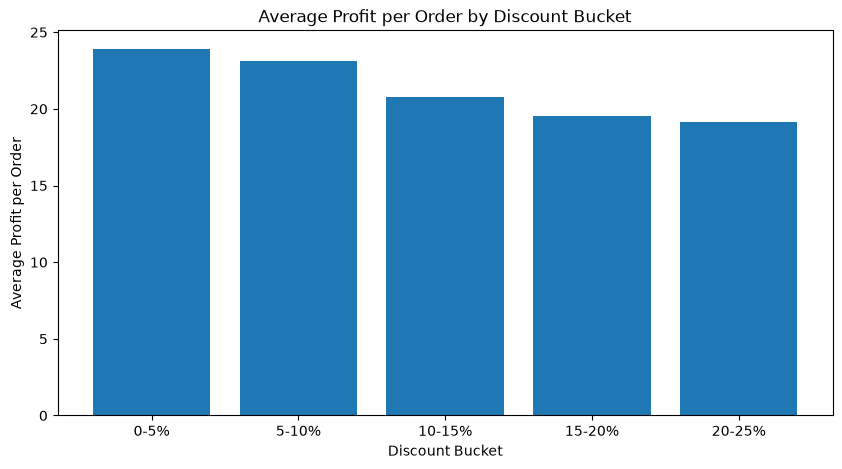

In [63]:
plt.figure(figsize=(10,5))

plt.bar(
    discount_threshold["Discount Bucket"],
    discount_threshold["Avg_Profit"]
)

plt.title("Average Profit per Order by Discount Bucket")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Profit per Order")

plt.show()

In [64]:
print(discount_threshold[
    ["Discount Bucket",
     "Avg_Profit_Margin",
     "Avg_Profit"]
])

  Discount Bucket  Avg_Profit_Margin  Avg_Profit
0            0-5%           0.122081   23.916745
1           5-10%           0.122668   23.095813
2          10-15%           0.117898   20.784363
3          15-20%           0.116907   19.544845
4          20-25%           0.127158   19.134183


In [65]:
# Shape of dataset
print("Dataset Shape:", df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Dataset Shape: (180519, 43)

Rows: 180519
Columns: 43

Column Names:
1. Type
2. Days for shipping (real)
3. Days for shipment (scheduled)
4. Benefit per order
5. Sales per customer
6. Delivery Status
7. Late_delivery_risk
8. Category Id
9. Category Name
10. Customer City
11. Customer Country
12. Customer Fname
13. Customer Id
14. Customer Lname
15. Customer Segment
16. Customer State
17. Customer Street
18. Department Id
19. Department Name
20. Latitude
21. Longitude
22. Market
23. Order City
24. Order Country
25. Order Customer Id
26. Order Item Discount
27. Order Item Discount Rate
28. Order Item Product Price
29. Order Item Profit Ratio
30. Order Item Quantity
31. Sales
32. Order Item Total
33. Order Profit Per Order
34. Order Region
35. Order State
36. Order Status
37. Product Name
38. Product Price
39. Shipping Mode
40. Discount Range
41. Sales Without Discount
42. Estimated Profit Without Discount
43. Discount Bucket


In [66]:
# Basic information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 43 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Type                               180519 non-null  str     
 1   Days for shipping (real)           180519 non-null  int64   
 2   Days for shipment (scheduled)      180519 non-null  int64   
 3   Benefit per order                  180519 non-null  float64 
 4   Sales per customer                 180519 non-null  float64 
 5   Delivery Status                    180519 non-null  str     
 6   Late_delivery_risk                 180519 non-null  int64   
 7   Category Id                        180519 non-null  int64   
 8   Category Name                      180519 non-null  str     
 9   Customer City                      180519 non-null  str     
 10  Customer Country                   180519 non-null  str     
 11  Customer Fname                     18